## Big Data for Marketing | Group 12 Project 2026
* Dataset 2: Twitch Gamers Social Network
* Following: GraphFrame
* Group 12 composition:
Anamaria Mois 20250916,
David Charneca 20250622,
Luana Costa 20250618,
Md Morshadul Alam 20221105,
Paulo Teixeira 20250565

### Questions to answer:
* How many communities there are here?
* Who is the most influencial: in degrees and per communities

## 0 - Environment Setup

In [1]:
!pip install "pyspark==3.5.0" graphframes-py==0.10.0 -q

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PYSPARK_SUBMIT_ARGS"] = "--packages io.graphframes:graphframes-spark3_2.12:0.10.0 pyspark-shell"

print("Environment ready!")

Environment ready!


In [2]:
import tempfile
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BigDataProject-GraphFrames") \
    .config("spark.jars.packages", "io.graphframes:graphframes-spark3_2.12:0.10.0") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "12g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

checkpoint_dir = tempfile.mkdtemp()
spark.sparkContext.setCheckpointDir(checkpoint_dir)

print(f"Spark version: {spark.version}")
print("Ready!")

:: loading settings :: url = jar:file:/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/zeus/.ivy2/cache
The jars for the packages stored in: /home/zeus/.ivy2/jars
io.graphframes#graphframes-spark3_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d462ee3c-91f8-46bd-8b80-bf53bbe41e5a;1.0
	confs: [default]
	found io.graphframes#graphframes-spark3_2.12;0.10.0 in central
	found io.graphframes#graphframes-graphx-spark3_2.12;0.10.0 in central
:: resolution report :: resolve 161ms :: artifacts dl 8ms
	:: modules in use:
	io.graphframes#graphframes-graphx-spark3_2.12;0.10.0 from central in [default]
	io.graphframes#graphframes-spark3_2.12;0.10.0 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||  

Spark version: 3.5.0
Ready!


In [3]:
from graphframes import *
from pyspark.sql.functions import col

## 1 - GraphFrame application to Twitch Social Network

In [4]:
# Load datasets
import os
nodes_path = "../data/large_twitch_features.csv"
edges_path = "../data/large_twitch_edges.csv"
if not os.path.exists(nodes_path):
    nodes_path = "large_twitch_features.csv"
if not os.path.exists(edges_path):
    edges_path = "large_twitch_edges.csv"
if not os.path.exists(nodes_path):
    nodes_path = "Datasetes/large_twitch_features.csv"
if not os.path.exists(edges_path):
    edges_path = "Datasetes/large_twitch_edges.csv"

nodes_df = spark.read.csv(nodes_path, header=True, inferSchema=True)
edges_df = spark.read.csv(edges_path, header=True, inferSchema=True)


In [5]:
#Quick look at the nodes data frame
nodes_df.show(5)

+------+------+---------+----------+----------+----------+------------+--------+---------+
| views|mature|life_time|created_at|updated_at|numeric_id|dead_account|language|affiliate|
+------+------+---------+----------+----------+----------+------------+--------+---------+
|  7879|     1|      969|2016-02-16|2018-10-12|         0|           0|      EN|        1|
|   500|     0|     2699|2011-05-19|2018-10-08|         1|           0|      EN|        0|
|382502|     1|     3149|2010-02-27|2018-10-12|         2|           0|      EN|        1|
|   386|     0|     1344|2015-01-26|2018-10-01|         3|           0|      EN|        0|
|  2486|     0|     1784|2013-11-22|2018-10-11|         4|           0|      EN|        0|
+------+------+---------+----------+----------+----------+------------+--------+---------+
only showing top 5 rows



In [6]:
#Quick look at the edges data frame
edges_df.show(5)

+------------+------------+
|numeric_id_1|numeric_id_2|
+------------+------------+
|       98343|      141493|
|       98343|       58736|
|       98343|      140703|
|       98343|      151401|
|       98343|      157118|
+------------+------------+
only showing top 5 rows



In [7]:
#Prepare Vertices (Nodes)
#Renaming the existing 'numeric_id' column to 'id'
vertices = nodes_df.withColumnRenamed("numeric_id", "id")

# Prepare Edges (Relationships)
edges = edges_df.withColumnRenamed("numeric_id_1", "src") \
                 .withColumnRenamed("numeric_id_2", "dst")

#Build the GraphFrame
TwitchGraph = GraphFrame(vertices, edges)

##### How many edges and vertices are their in the graph?

In [8]:
# Checking row counts to understand the scale of the network before processing
print(f"Total Twitch Users (Vertices): {TwitchGraph.vertices.count():,}")
print(f"Total Follower Connections (Edges): {TwitchGraph.edges.count():,}")

Total Twitch Users (Vertices): 168,114


Total Follower Connections (Edges): 6,797,557


##### Some analysis

In [9]:
# View the inDegrees (the number of edges directed into a vertex)
TwitchGraph.inDegrees.show(5)

+------+--------+
|    id|inDegree|
+------+--------+
|116648|       3|
|145281|       5|
| 16783|       2|
| 75403|       3|
| 78899|      12|
+------+--------+
only showing top 5 rows



In [10]:
# View the outDegrees (the number of edges directed out of a vertex)
TwitchGraph.outDegrees.show(5)

+------+---------+
|    id|outDegree|
+------+---------+
|116648|     5921|
|145281|      345|
| 16783|     1554|
| 75403|     2147|
| 78899|     2031|
+------+---------+
only showing top 5 rows



##### VISUALIZATION OF THE NETWORK

### Pagerank

In [11]:
# For big data, we will keep the maxIter to 5 since it's the number of iteractions
twitch_pagerank = TwitchGraph.pageRank(resetProbability=0.15, maxIter=5)

print("Top 10 most influential Twitch streamers based on PageRank:")
# Ordering the results:
twitch_pagerank.vertices.orderBy(col("pagerank").desc()).show(10)

26/06/04 16:48:48 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/04 16:48:48 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/04 16:49:15 WARN PageRank: Returned DataFrame is persistent and materialized!


Top 10 most influential Twitch streamers based on PageRank:
+------+------+---------+----------+----------+------+------------+--------+---------+------------------+
| views|mature|life_time|created_at|updated_at|    id|dead_account|language|affiliate|          pagerank|
+------+------+---------+----------+----------+------+------------+--------+---------+------------------+
|  2030|     0|      396|2017-09-02|2018-10-03| 68971|           0|      EN|        1|  31.8379689232941|
|   680|     0|      176|2018-04-19|2018-10-12|154952|           0|      EN|        1|28.769032120504697|
|   623|     1|      307|2017-11-30|2018-10-03| 71923|           0|      EN|        0|23.915819806265684|
|  1141|     0|      940|2016-03-16|2018-10-12| 42873|           0|      EN|        1|23.797966731120955|
|130339|     0|     1675|2014-03-11|2018-10-11| 93839|           0|      EN|        1|22.923632309042972|
|  6773|     1|     1491|2014-09-09|2018-10-09|154071|           0|      EN|        1| 22.30

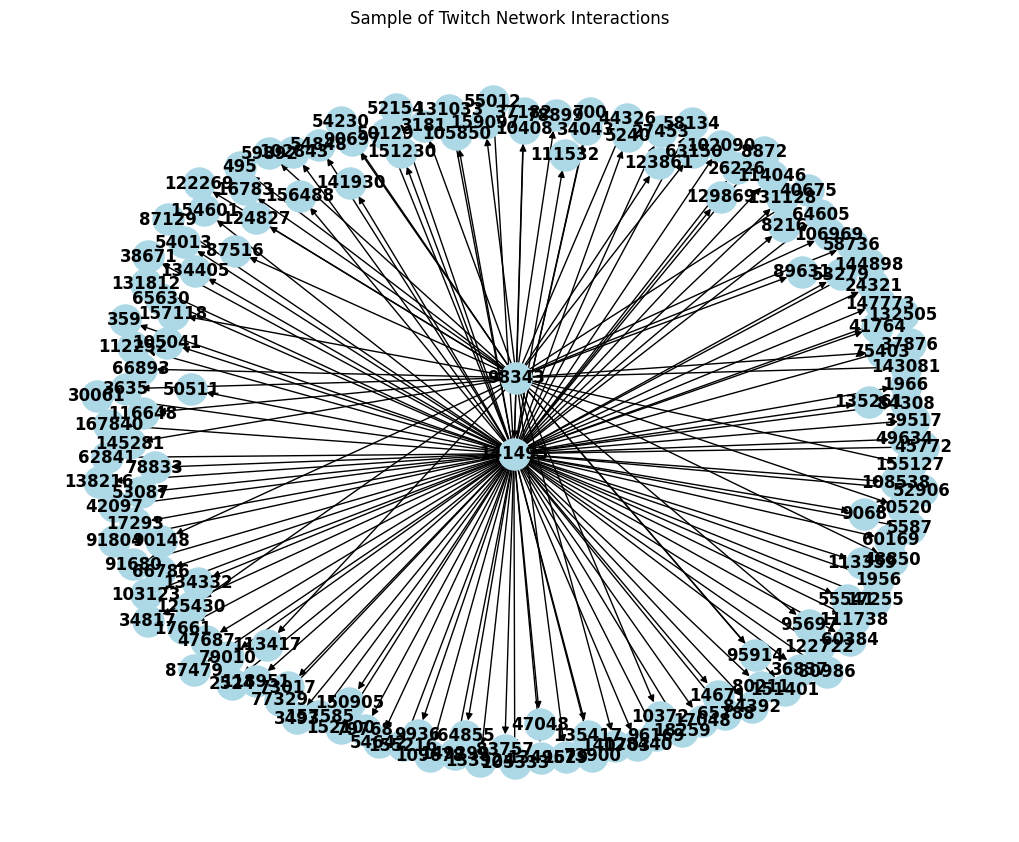

In [12]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

sample_edges_df = TwitchGraph.edges.limit(150).toPandas()

#Creating the Graph:
G_twitch = nx.from_pandas_edgelist(
    sample_edges_df, 
    source='src', 
    target='dst', 
    create_using=nx.DiGraph()
)

plt.figure(figsize=(10, 8))
nx.draw(
    G_twitch, 
    with_labels=True, 
    node_color='lightblue', 
    node_size=500,
    font_weight='bold', 
    arrows=True
)
plt.title("Sample of Twitch Network Interactions")
plt.show()

In [13]:
# CELL: GRAPH SUMMARY

print(f"Total Twitch Users (Vertices): {TwitchGraph.vertices.count():,}")
print(f"Total Connections  (Edges):    {TwitchGraph.edges.count():,}")
TwitchGraph.vertices.printSchema()
TwitchGraph.edges.printSchema()

Total Twitch Users (Vertices): 168,114


Total Connections  (Edges):    6,797,557
root
 |-- views: integer (nullable = true)
 |-- mature: integer (nullable = true)
 |-- life_time: integer (nullable = true)
 |-- created_at: date (nullable = true)
 |-- updated_at: date (nullable = true)
 |-- id: integer (nullable = true)
 |-- dead_account: integer (nullable = true)
 |-- language: string (nullable = true)
 |-- affiliate: integer (nullable = true)

root
 |-- src: integer (nullable = true)
 |-- dst: integer (nullable = true)



In [14]:
# Who is most followed?
# Top 10 most followed streamers (highest in-degree)
print("=== TOP 10 MOST FOLLOWED STREAMERS ===")
TwitchGraph.inDegrees \
    .join(TwitchGraph.vertices, on="id") \
    .select("id", "views", "inDegree") \
    .orderBy(col("inDegree").desc()) \
    .show(10)

# Top 10 most active followers (highest out-degree)
print("=== TOP 10 MOST ACTIVE FOLLOWERS ===")
TwitchGraph.outDegrees \
    .join(TwitchGraph.vertices, on="id") \
    .select("id", "views", "outDegree") \
    .orderBy(col("outDegree").desc()) \
    .show(10)

=== TOP 10 MOST FOLLOWED STREAMERS ===


+------+-------+--------+
|    id|  views|inDegree|
+------+-------+--------+
|148398|1774586|    1048|
|101472|1488098|     905|
|138436|3761906|     861|
| 47968| 836104|     810|
|104231|1695510|     795|
|122133| 216749|     780|
|121730|  77002|     763|
|136179| 885067|     749|
| 21913|7365538|     739|
| 77701|4932901|     722|
+------+-------+--------+
only showing top 10 rows

=== TOP 10 MOST ACTIVE FOLLOWERS ===


+------+---------+---------+
|    id|    views|outDegree|
+------+---------+---------+
| 61862|340602050|    35208|
|125642|243451177|    31036|
| 32338|202142952|    30463|
| 71050|218559516|    29905|
|110345|264643346|    22601|
| 64605|240718261|    20660|
| 52703|206941623|    18679|
|155127| 18896216|    18345|
| 60588| 99791351|    14605|
|123018|108115325|    14398|
+------+---------+---------+
only showing top 10 rows



In [15]:
# PAGERANK — Most influential streamers
# PageRank measures influence based on WHO follows you
# maxIter=5 → big-data safe: limits computation on large graphs

twitch_pagerank = TwitchGraph.pageRank(resetProbability=0.15, maxIter=5)

print("=== TOP 10 MOST INFLUENTIAL STREAMERS (PageRank) ===")
twitch_pagerank.vertices \
    .select("id", "views", "pagerank") \
    .orderBy(col("pagerank").desc()) \
    .show(10)

26/06/04 16:49:27 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/04 16:49:27 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/04 16:49:47 WARN PageRank: Returned DataFrame is persistent and materialized!


=== TOP 10 MOST INFLUENTIAL STREAMERS (PageRank) ===
+------+------+------------------+
|    id| views|          pagerank|
+------+------+------------------+
| 68971|  2030|  31.8379689232941|
|154952|   680|28.769032120504697|
| 71923|   623|23.915819806265684|
| 42873|  1141|23.797966731120955|
| 93839|130339|22.923632309042972|
|154071|  6773| 22.30877084436452|
| 43886|   913|20.375404195693847|
| 62551|  7101|20.255543463210834|
|129738| 57099| 19.78769654977558|
|156524|277277| 18.46675657082547|
+------+------+------------------+
only showing top 10 rows



In [16]:
# CONNECTED COMPONENTS
# Finds isolated communities — groups of streamers who are. connected to each other but not to the rest of the network
# Marketing use: identify niche communities for targeted campaigns

cc = TwitchGraph.connectedComponents()

print("=== CONNECTED COMPONENTS ===")
cc.groupBy("component") \
  .count() \
  .orderBy(col("count").desc()) \
  .show(10)

print(f"\nTotal distinct communities: {cc.select('component').distinct().count()}")

26/06/04 16:50:30 WARN ConnectedComponents$: Returned DataFrame is persistent and materialized!


=== CONNECTED COMPONENTS ===
+---------+------+
|component| count|
+---------+------+
|        0|168114|
+---------+------+


Total distinct communities: 1


In [17]:
# Build sampled graph — top 10,000 nodes by in-degree
top_nodes = TwitchGraph.inDegrees \
    .orderBy(col("inDegree").desc()) \
    .limit(10000)

sampled_vertices = vertices.join(top_nodes.select("id"), on="id")
sampled_edges = edges \
    .join(top_nodes.select(col("id").alias("src")), on="src") \
    .join(top_nodes.select(col("id").alias("dst")), on="dst")

SampledGraph = GraphFrame(sampled_vertices, sampled_edges)
SampledGraph.vertices.cache()
SampledGraph.edges.cache()

print(f"Sampled: {SampledGraph.vertices.count():,} nodes, {SampledGraph.edges.count():,} edges")

Sampled: 10,000 nodes, 727,102 edges


In [18]:
from pyspark import StorageLevel
# TRIANGLE COUNT — Sampled Graph

tc = SampledGraph.triangleCount(StorageLevel.MEMORY_AND_DISK)

tc.select("id", "count", "views") \
  .orderBy(col("count").desc()) \
  .show(10)

26/06/04 16:50:46 WARN AggregateMessages: Returned DataFrame is persistent and materialized!
26/06/04 16:51:04 WARN TriangleCount$: Returned DataFrame is persistent and materialized!


+------+------+--------+
|    id| count|   views|
+------+------+--------+
|111372|104129|62560909|
| 42605| 92590| 6527692|
| 12481| 78262|10083919|
|113707| 72478|20516537|
|137373| 70582| 9066312|
| 94108| 61525|12124358|
| 87132| 61216| 6101710|
| 21913| 59596| 7365538|
|137899| 58859|13245131|
| 80986| 57618|15019409|
+------+------+--------+
only showing top 10 rows



In [19]:
# GRAPHFRAMES MARKETING INSIGHTS SUMMARY
from pyspark.sql.functions import avg

print("=" * 60)
print("GRAPHFRAMES MARKETING INSIGHTS SUMMARY")
print("=" * 60)

# 1. Network scale
print(f"\n1. Network Scale:")
print(f"   Total streamers:   {TwitchGraph.vertices.count():,}")
print(f"   Total connections: {TwitchGraph.edges.count():,}")

# 2. Top influencer
top = twitch_pagerank.vertices.orderBy(col("pagerank").desc()).first()
print(f"\n2. Top Influencer (PageRank):")
print(f"   Streamer ID: {top['id']} | Views: {top['views']:,} | PageRank: {top['pagerank']:.4f}")

# 3. Community count
n_communities = cc.select("component").distinct().count()
print(f"\n3. Communities Found: {n_communities:,}")
print(f"   Targeted campaigns can be tailored per community")

# 4. Top 3 by in-degree
print(f"\n4. Top 3 Most Followed Streamers:")
TwitchGraph.inDegrees \
    .join(TwitchGraph.vertices, on="id") \
    .select("id", "views", "inDegree") \
    .orderBy(col("inDegree").desc()) \
    .limit(3) \
    .show()

print("\nMarketing Recommendation:")
print("   → Focus campaigns on top PageRank streamers for maximum reach")
print("   → Each community represents a niche audience for targeted ads")
print("   → Most-followed streamers are ideal brand ambassador candidates")

GRAPHFRAMES MARKETING INSIGHTS SUMMARY

1. Network Scale:
   Total streamers:   168,114


   Total connections: 6,797,557

2. Top Influencer (PageRank):
   Streamer ID: 68971 | Views: 2,030 | PageRank: 31.8380

3. Communities Found: 1
   Targeted campaigns can be tailored per community

4. Top 3 Most Followed Streamers:


+------+-------+--------+
|    id|  views|inDegree|
+------+-------+--------+
|148398|1774586|    1048|
|101472|1488098|     905|
|138436|3761906|     861|
+------+-------+--------+


Marketing Recommendation:
   → Focus campaigns on top PageRank streamers for maximum reach
   → Each community represents a niche audience for targeted ads
   → Most-followed streamers are ideal brand ambassador candidates


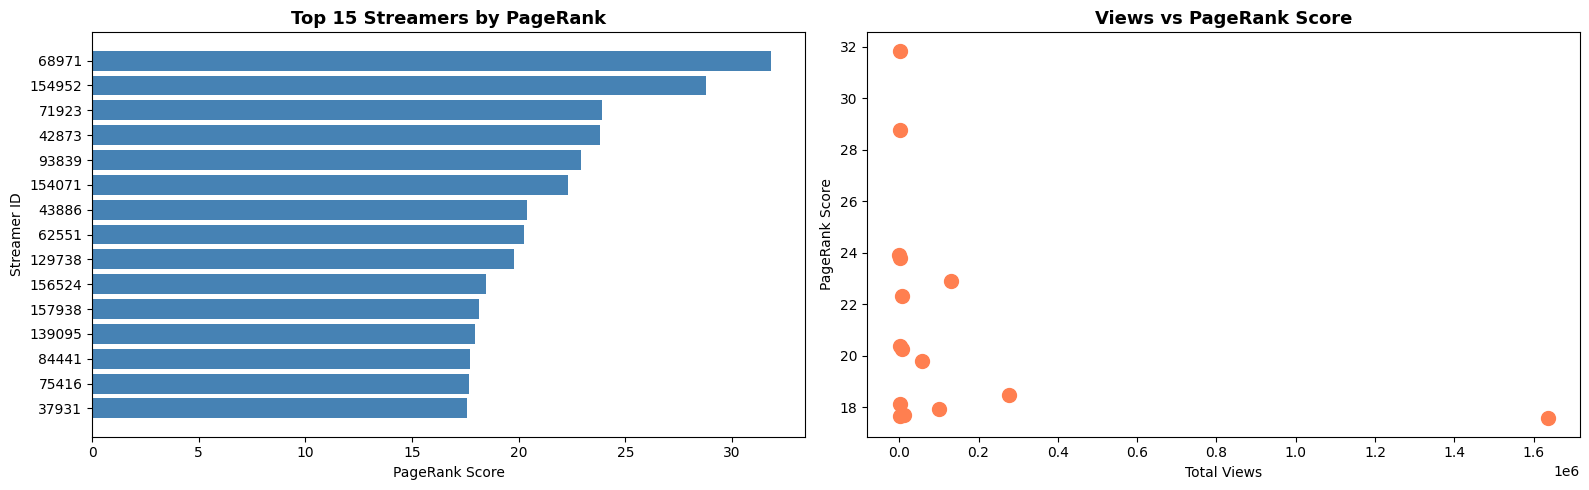

In [20]:
# CELL: VISUALISATION — PageRank top streamers
import matplotlib.pyplot as plt

pagerank_pd = twitch_pagerank.vertices \
    .select("id", "views", "pagerank") \
    .orderBy(col("pagerank").desc()) \
    .limit(15) \
    .toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1 — PageRank scores
ax1.barh(pagerank_pd["id"].astype(str), pagerank_pd["pagerank"], color="steelblue")
ax1.set_title("Top 15 Streamers by PageRank", fontsize=13, fontweight="bold")
ax1.set_xlabel("PageRank Score")
ax1.set_ylabel("Streamer ID")
ax1.invert_yaxis()

# Chart 2 — Views vs PageRank
ax2.scatter(pagerank_pd["views"], pagerank_pd["pagerank"], color="coral", s=100)
ax2.set_title("Views vs PageRank Score", fontsize=13, fontweight="bold")
ax2.set_xlabel("Total Views")
ax2.set_ylabel("PageRank Score")

plt.tight_layout()
plt.show()

In [21]:
# TOP INFLUENCER PER COMMUNITY
# Marketing: who to target for each niche audience?

from pyspark.sql import Window
from pyspark.sql.functions import row_number

# Sample the data 
sampled_pagerank = SampledGraph.pageRank(resetProbability=0.15, maxIter=5)

# Join PageRank scores with community labels
pagerank_with_community = sampled_pagerank.vertices \
    .join(cc.select("id", "component"), on="id")

# Get top influencer per community
window = Window.partitionBy("component").orderBy(col("pagerank").desc())

top_per_community = pagerank_with_community \
    .withColumn("rank", row_number().over(window)) \
    .filter(col("rank") == 1) \
    .select("component", "id", "views", "pagerank") \
    .orderBy(col("pagerank").desc())

print("=== TOP INFLUENCER PER COMMUNITY ===")
top_per_community.show(10, truncate=False)

26/06/04 16:51:10 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/04 16:51:10 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/06/04 16:51:13 WARN PageRank: Returned DataFrame is persistent and materialized!


=== TOP INFLUENCER PER COMMUNITY ===
+---------+----+-----+-----------------+
|component|id  |views|pagerank         |
+---------+----+-----+-----------------+
|0        |2563|2542 |46.88120040586219|
+---------+----+-----+-----------------+



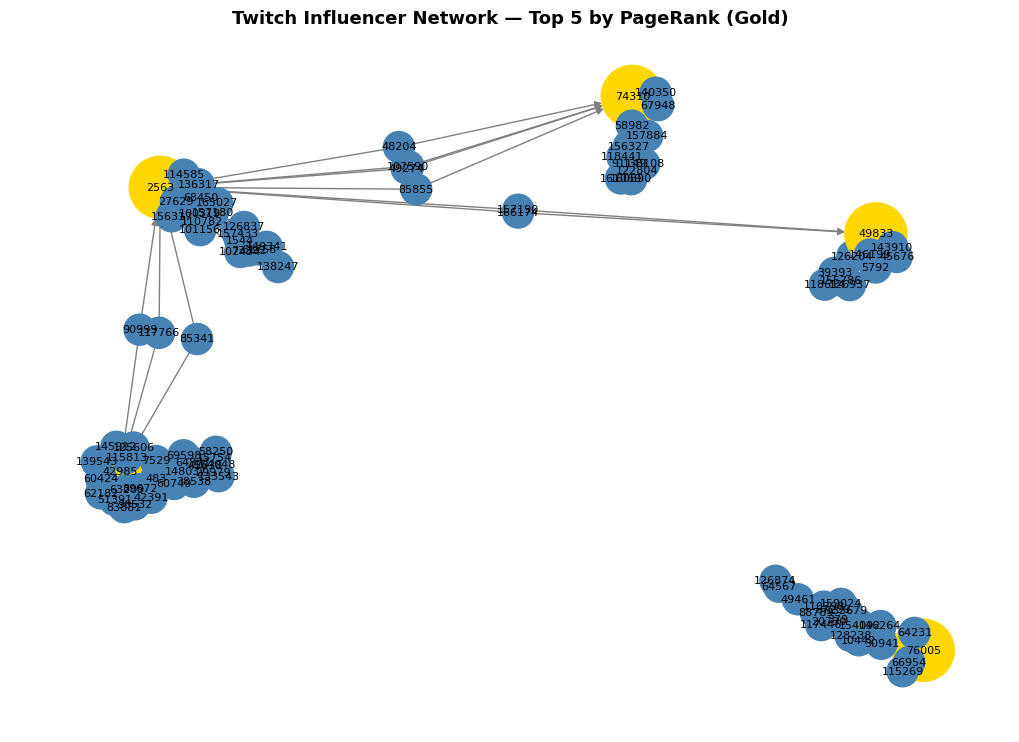

In [22]:
import matplotlib.pyplot as plt
import networkx as nx

# Top 5 influencers by PageRank for clean visualisation
top5_ids = sampled_pagerank.vertices \
    .orderBy(col("pagerank").desc()) \
    .limit(5) \
    .select("id") \
    .rdd.flatMap(lambda x: x).collect()

# Get edges between top 5 only
top5_edges = SampledGraph.edges \
    .filter(col("src").isin(top5_ids) | col("dst").isin(top5_ids)) \
    .limit(100) \
    .toPandas()

# Build NetworkX graph
G = nx.from_pandas_edgelist(
    top5_edges, source="src", target="dst",
    create_using=nx.DiGraph()
)

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos,
    with_labels=True,
    node_color=["gold" if n in top5_ids else "steelblue" for n in G.nodes()],
    node_size=[2000 if n in top5_ids else 500 for n in G.nodes()],
    font_size=8,
    arrows=True,
    edge_color="grey"
)
plt.title("Twitch Influencer Network — Top 5 by PageRank (Gold)", 
          fontsize=13, fontweight="bold")
plt.show()